## Download the dataset of school location


In [15]:
from urllib.request import urlretrieve
import os

# url for school external datasets and save in "landing" dirctory for sebsequent processing
names = ["school_location_2023"] 
URLS = ['https://www.education.vic.gov.au/Documents/about/research/datavic/dv346-schoollocations2023.csv']
# Create a directory path for storing externally downloaded population data.
output_relpop = '../../data/landing/external_data/'

if not os.path.exists(output_relpop):
    os.makedirs(output_relpop)


# Download the files and save them in the "landing" directory
for i in range(len(names)):
    URLS_TEMPLATE = URLS[i]

    output_dir = output_relpop 
    url = f'{URLS_TEMPLATE}'

    output_dir = f"{output_dir}/{names[i]}.csv"

    urlretrieve(url, output_dir) 

In [16]:
import requests

specific_data_url = 'https://www.education.vic.gov.au/Documents/about/research/datavic/dv346-schoollocations2023.csv'
output_path = '../../data/landing/external_data/school_location.csv'

headers = {
     'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36'
}
#response = requests.get(specific_data_url, headers=headers)
#response = requests.get(specific_data_url, verify=False)
response = requests.get(specific_data_url, headers=headers, verify=True, timeout=10, stream=True, allow_redirects=True, cert=None, proxies=None)
response.raise_for_status()
with open(output_path, 'wb') as out_file:
    out_file.write(response.content)

## Prepropcessing 

In [17]:
import pandas as pd
import openpyxl

In [18]:
school = pd.read_csv('../../data/landing/external_data/School_location.csv',encoding='ISO-8859-1')
school =  school[['School_Name','Address_Postcode','X', 'Y']]
school
#sheet_list=school.sheet_names
#sheet_list
school.to_csv('../../data/raw/external_data/School_location.csv')

In [19]:
school.sort_values('X',ascending=True)

,School_Name,Address_Postcode,X,Y
189,Apsley Primary School,3319,141.08249,-36.97371
1116,Murrayville Community College,3512,141.17734,-35.26557
1516,Kaniva College,3419,141.24485,-36.38272
146,Dartmoor Primary School,3304,141.27673,-37.92302
1115,Edenhope College,3318,141.29856,-37.03343
...,...,...,...,...
1390,Orbost Secondary College,3888,148.46635,-37.70411
528,Marlo Primary School,3888,148.53504,-37.79627
592,Cann River P-12 College,3890,149.15302,-37.56970
537,Mallacoota P-12 College,3892,149.75430,-37.55943


In [20]:
# Create a GeoSeries representing school locations as Points
school['geometry'] = [[x, y] for x, y in zip(school['X'], school['Y'])]

geometry_school = school[['School_Name','Address_Postcode','geometry']]
geometry_school.to_csv('../../data/curated/external_data/School_location.csv')

In [21]:
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

In [22]:
#shapefile = gpd.read_file('../../data/landing/external_data/shapefile/SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp')
#shapefile=shapefile[['SA2_NAME21','geometry']]
geoJSON = geometry_school[['School_Name', 'geometry']].to_json()

In [23]:
import folium
_map = folium.Map(location=[-37.81, 144.96], tiles="cartodb positron", zoom_start=9)

In [24]:
sample_geometry_school = geometry_school.sample(frac=0.1)

In [25]:
sample_geometry_school

,School_Name,Address_Postcode,geometry
516,Kongwak Primary School,3951,"[145.71286, -38.51511]"
1327,Doncaster Secondary College,3108,"[145.13805, -37.78458]"
766,Frankston Heights Primary School,3199,"[145.14717, -38.16181]"
1395,Pascoe Vale Girls Secondary College,3044,"[144.9355, -37.71756]"
424,Rosebud Primary School,3939,"[144.909, -38.35576]"
...,...,...,...
1039,Thomas Mitchell Primary School,3802,"[145.27391, -37.98056]"
2025,St Paul's Kealba Catholic School,3021,"[144.81963, -37.73374]"
2174,Aitken College,3059,"[144.8907, -37.62771]"
592,Cann River P-12 College,3890,"[149.15302, -37.5697]"


In [26]:
# sampling the school amount and draw a geospatial plot

for index, row in sample_geometry_school.iterrows():
    zone_name = row['School_Name']
    # Convert the string representation to an actual list
    coord = row['geometry']
    _map.add_child(
        folium.Marker(location=coord, popup=zone_name)
    )

_map.save('../../plots/school_location.html')
_map

In [30]:

# shape file of the sa2 in victoria 
SA2_sf = gpd.read_file('../../data/landing/external_data/shapefile/SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp')
SA2_gdf = gpd.GeoDataFrame(SA2_sf)
SA2_gdf_vic = SA2_gdf[SA2_gdf['STE_NAME21'] =='Victoria']
SA2 =  SA2_gdf_vic[['SA2_CODE21','SA2_NAME21','geometry']]
SA2_vic = SA2.dropna().reset_index(drop=True)
SA2_vic

,SA2_CODE21,SA2_NAME21,geometry
0,201011001,Alfredton,"POLYGON ((143.78282 -37.56666, 143.75558 -37.5..."
1,201011002,Ballarat,"POLYGON ((143.81896 -37.55582, 143.81644 -37.5..."
2,201011005,Buninyong,"POLYGON ((143.84171 -37.61596, 143.84176 -37.6..."
3,201011006,Delacombe,"POLYGON ((143.75050 -37.59119, 143.75044 -37.5..."
4,201011007,Smythes Creek,"POLYGON ((143.73296 -37.62333, 143.73263 -37.6..."
...,...,...,...
517,217031476,Otway,"MULTIPOLYGON (((143.40263 -38.78152, 143.40252..."
518,217041477,Moyne - East,"POLYGON ((142.41438 -38.09303, 142.41400 -38.0..."
519,217041478,Moyne - West,"MULTIPOLYGON (((142.00870 -38.41715, 142.00876..."
520,217041479,Warrnambool - North,"POLYGON ((142.43668 -38.35544, 142.43658 -38.3..."


In [31]:
SA2[SA2['geometry']!='None']

,SA2_CODE21,SA2_NAME21,geometry
644,201011001,Alfredton,"POLYGON ((143.78282 -37.56666, 143.75558 -37.5..."
645,201011002,Ballarat,"POLYGON ((143.81896 -37.55582, 143.81644 -37.5..."
646,201011005,Buninyong,"POLYGON ((143.84171 -37.61596, 143.84176 -37.6..."
647,201011006,Delacombe,"POLYGON ((143.75050 -37.59119, 143.75044 -37.5..."
648,201011007,Smythes Creek,"POLYGON ((143.73296 -37.62333, 143.73263 -37.6..."
...,...,...,...
1163,217041478,Moyne - West,"MULTIPOLYGON (((142.00870 -38.41715, 142.00876..."
1164,217041479,Warrnambool - North,"POLYGON ((142.43668 -38.35544, 142.43658 -38.3..."
1165,217041480,Warrnambool - South,"POLYGON ((142.45281 -38.39126, 142.45230 -38.3..."
1166,297979799,Migratory - Offshore - Shipping (Vic.),None


In [32]:
from shapely.geometry import Point

geometry = [Point(XY) for XY in zip(school['X'], school['Y'])]
schools = gpd.GeoDataFrame(school, geometry=geometry)

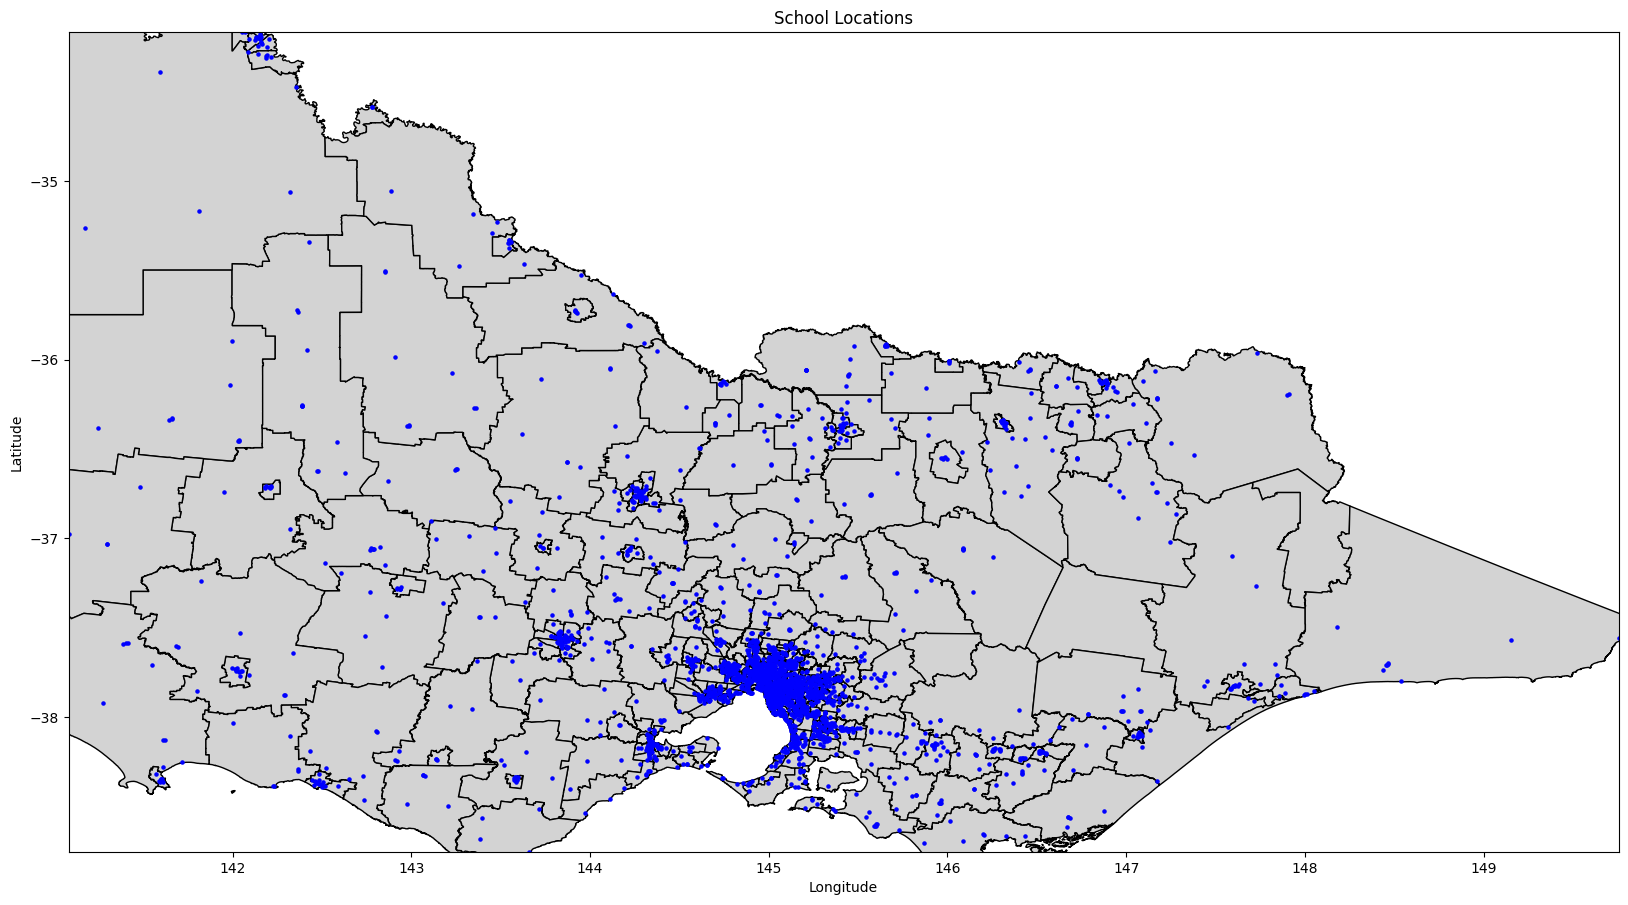

In [35]:
fig, ax = plt.subplots(figsize=(20, 20))

# Plot the shapefile

SA2_vic.plot(ax=ax, color='lightgray', edgecolor='k')
# Plot school locations
schools.plot(ax=ax, color='blue', markersize=5)

# Set plot title and axis labels
plt.title('School Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.set_xlim(141.082487, 149.754296)  # Set the desired longitude range
ax.set_ylim(-38.753524, -34.166857)  # Set the desired latitude range

# Show the plot
plt.show()